In [644]:
import requests
import matplotlib.pyplot as plt

In [645]:
base_url = 'https://www.dnd5eapi.co' 
search_path = '/api/2014/spells' 

In [646]:
spellslist = requests.get(base_url + search_path)

In [647]:
parsedspells = spellslist.json()

In [648]:
spelldicts = parsedspells['results']

In [649]:
allspells = []

for i in spelldicts:
    allspells.append(i['index'])

In [650]:
spells_path = '/api/2014/spells/'
spellname = []
spelllevel = []
spellschool = []
spellclass = []
spellsubclass = []

for i in allspells:
    spell_index = i
    spellurl = (f'{base_url}{spells_path}{i}')
    spellcontent = requests.get(spellurl).json()
    
    for x in spellcontent['classes']:
        spellname.append(spellcontent['name'])
        spelllevel.append(spellcontent['level'])
        spellschool.append(spellcontent['school']['index'])  
        classdict = x
        spellclass.append(classdict['index'])
        spellsubclass.append("all")
    
    for z in spellcontent['subclasses']:
        spellname.append(spellcontent['name'])
        spellschool.append(spellcontent['school']['index'])
        spelllevel.append(spellcontent['level'])
        subclassdict = z
        spellsubclass.append(subclassdict['index'])
        
        if subclassdict['index'] == "lore":
            spellclass.append("bard")
        elif subclassdict['index'] == "land":
            spellclass.append("druid")
        elif subclassdict['index'] == "life":
            spellclass.append("cleric")
        elif subclassdict['index'] == "evoker":
            spellclass.append("wizard")
        elif subclassdict['index'] == "fiend":
            spellclass.append("warlock")
        elif subclassdict['index'] == "devotion":
            spellclass.append("paladin")
            

In [651]:
import pandas as pd

df = pd.DataFrame({
    'Spell Name' : spellname,
    'Spell Level': spelllevel,
    'Spell School' : spellschool,
    'Class' : spellclass,
    'Subclass' : spellsubclass
})
 
df

,Spell Name,Spell Level,Spell School,Class,Subclass
0,Acid Arrow,2,evocation,wizard,all
1,Acid Arrow,2,evocation,bard,lore
2,Acid Arrow,2,evocation,druid,land
3,Acid Splash,0,conjuration,sorcerer,all
4,Acid Splash,0,conjuration,wizard,all
...,...,...,...,...,...
1005,Zone of Truth,2,enchantment,bard,all
1006,Zone of Truth,2,enchantment,cleric,all
1007,Zone of Truth,2,enchantment,paladin,all
1008,Zone of Truth,2,enchantment,bard,lore


In [652]:
df.to_csv('spells final.csv')

In [653]:
classSpellLists = df[df['Subclass'] == 'all']
classSpellLists

,Spell Name,Spell Level,Spell School,Class,Subclass
0,Acid Arrow,2,evocation,wizard,all
3,Acid Splash,0,conjuration,sorcerer,all
4,Acid Splash,0,conjuration,wizard,all
6,Aid,2,abjuration,cleric,all
7,Aid,2,abjuration,paladin,all
...,...,...,...,...,...
1003,Wish,9,conjuration,wizard,all
1004,Word of Recall,6,conjuration,cleric,all
1005,Zone of Truth,2,enchantment,bard,all
1006,Zone of Truth,2,enchantment,cleric,all


In [654]:
classSpellLists.to_csv('class_spell_lists.csv')

In [655]:
abjuration = classSpellLists['Spell School'] == 'abjuration'
conjuration = classSpellLists['Spell School'] == 'conjuration'
divination = classSpellLists['Spell School'] == 'divination'
enchantment = classSpellLists['Spell School'] == 'enchantment'
evocation = classSpellLists['Spell School'] == 'evocation'
illusion = classSpellLists['Spell School'] == 'illusion'
necromancy = classSpellLists['Spell School'] == 'necromancy'
transmutation = classSpellLists['Spell School'] == 'transmutation'

In [656]:
abjurationClassSchool = classSpellLists[abjuration].value_counts('Class').sort_index()
conjurationClassSchool = classSpellLists[conjuration].value_counts('Class').sort_index()
divinationClassSchool = classSpellLists[divination].value_counts('Class').sort_index()
enchantmentClassSchool = classSpellLists[enchantment].value_counts('Class').sort_index()
evocationClassSchool = classSpellLists[evocation].value_counts('Class').sort_index()
illusionClassSchool = classSpellLists[illusion].value_counts('Class').sort_index()
necromancyClassSchool = classSpellLists[necromancy].value_counts('Class').sort_index()
transmutationClassSchool = classSpellLists[transmutation].value_counts('Class').sort_index()

necromancyClassSchool['ranger'] = 0
illusionClassSchool['paladin'] = 0

Text(0, 0.5, 'Number of Spells')

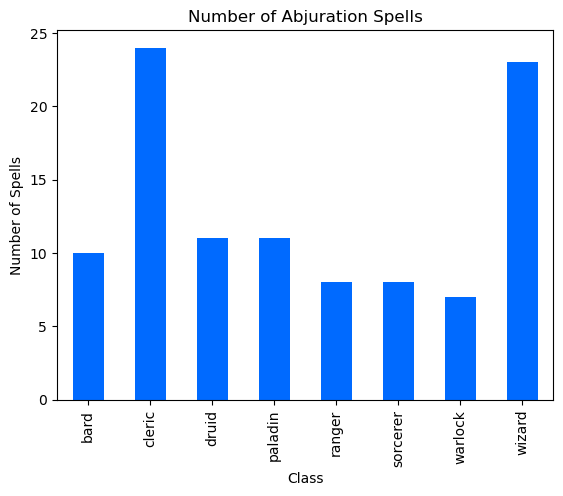

In [657]:
abjurationGraph = abjurationClassSchool.plot(kind = "bar", title = "Number of Abjuration Spells", color = "#006aff")
plt.ylabel('Number of Spells')

In [658]:
x = abjurationGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('abjuration_graph.png')

Text(0, 0.5, 'Number of Spells')

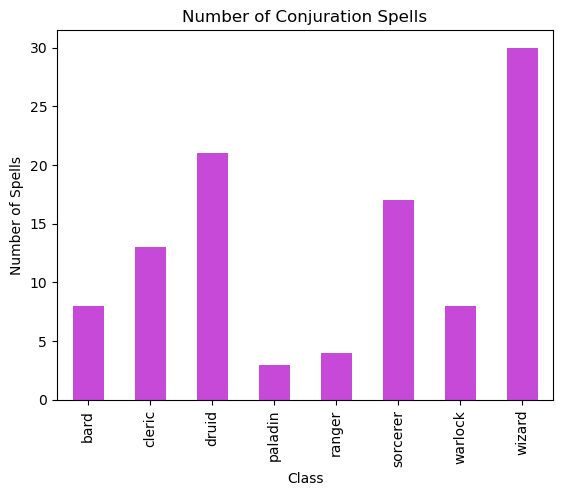

In [659]:
conjurationGraph = conjurationClassSchool.plot(kind = "bar", title = "Number of Conjuration Spells", color = "#c749d7")
plt.ylabel('Number of Spells')

In [660]:
x = conjurationGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('conjuration_graph.png')

Text(0, 0.5, 'Number of Spells')

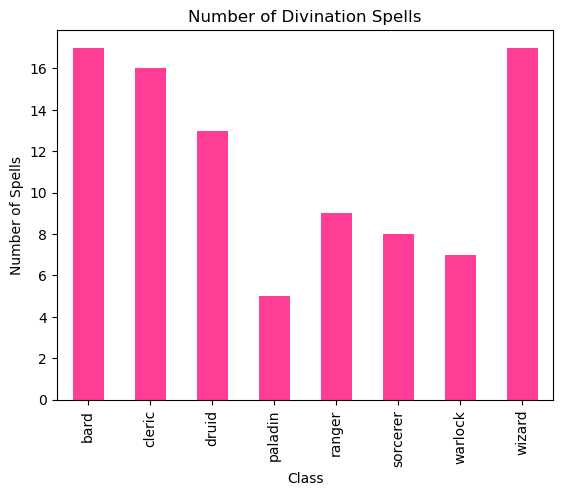

In [661]:
divinationGraph = divinationClassSchool.plot(kind = "bar", title = "Number of Divination Spells", color = "#ff3d94")
plt.ylabel('Number of Spells')

In [662]:
x = divinationGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('divination_graph.png')

Text(0, 0.5, 'Number of Spells')

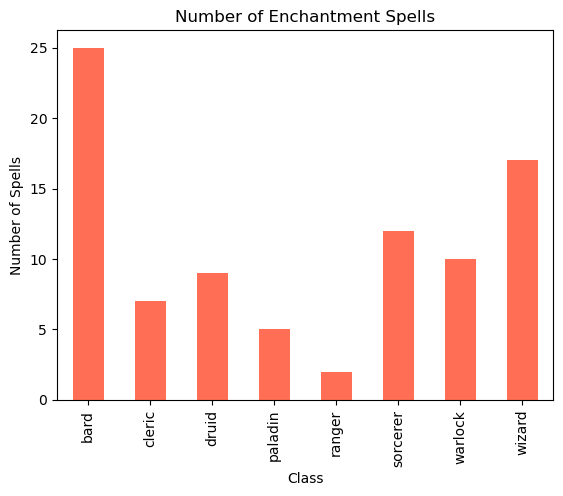

In [663]:
enchantmentGraph = enchantmentClassSchool.plot(kind = "bar", title = "Number of Enchantment Spells", color = "#ff6e55")
plt.ylabel('Number of Spells')

In [664]:
x = enchantmentGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('enchantment_graph.png')

Text(0, 0.5, 'Number of Spells')

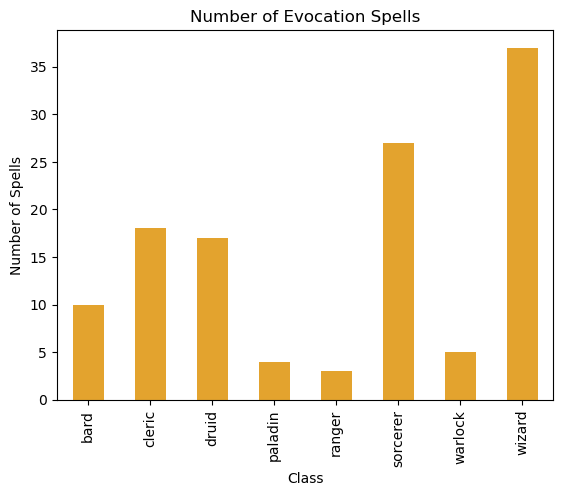

In [665]:
evocationGraph = evocationClassSchool.plot(kind = "bar", title = "Number of Evocation Spells", color = "#e3a32e")
plt.ylabel('Number of Spells')

In [666]:
x = evocationGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('evocation_graph.png')

Text(0, 0.5, 'Number of Spells')

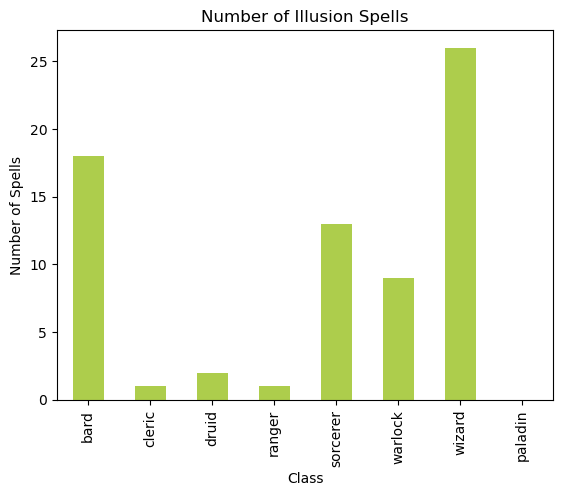

In [667]:
illusionGraph = illusionClassSchool.plot(kind = "bar", title = "Number of Illusion Spells", color = "#adcd4c")
plt.ylabel('Number of Spells')

In [668]:
x = illusionGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('illusion_graph.png')

Text(0, 0.5, 'Number of Spells')

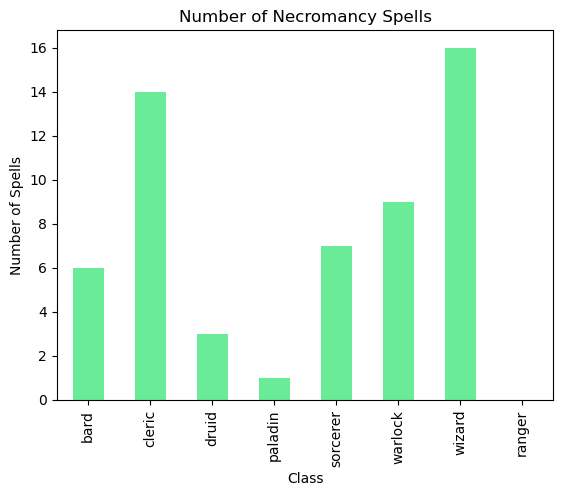

In [669]:
necromancyGraph = necromancyClassSchool.plot(kind = "bar", title = "Number of Necromancy Spells", color = "#69eb98")
plt.ylabel('Number of Spells')

In [670]:
x = necromancyGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('necromancy_graph.png')

Text(0, 0.5, 'Number of Spells')

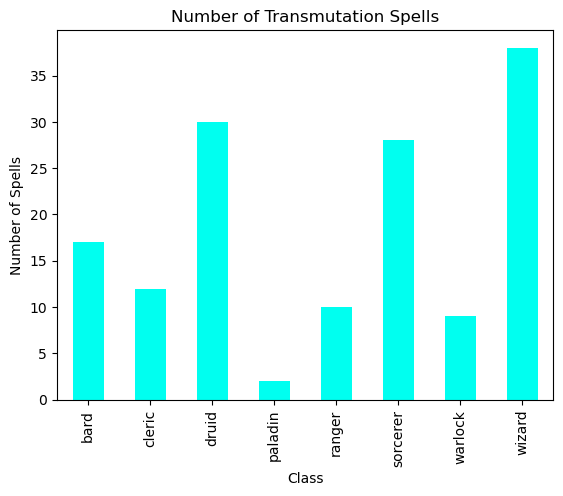

In [671]:
transmutationGraph = transmutationClassSchool.plot(kind = "bar", title = "Number of Transmutation Spells", color = "#00fff0")
plt.ylabel('Number of Spells')

In [672]:
x = transmutationGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('transmutation_graph.png')

In [673]:
combined_df = pd.merge(abjurationClassSchool, conjurationClassSchool, on='Class')
combined_df = pd.merge(combined_df, divinationClassSchool, on='Class')
combined_df.columns = ['Abjuration', 'Conjuration', 'Divination']
combined_df = pd.merge(combined_df, enchantmentClassSchool, on='Class')
combined_df.columns = ['Abjuration', 'Conjuration', 'Divination', 'Enchantment']
combined_df = pd.merge(combined_df, evocationClassSchool, on='Class')
combined_df.columns = ['Abjuration', 'Conjuration', 'Divination', 'Enchantment', 'Evocation']
combined_df = pd.merge(combined_df, illusionClassSchool, on='Class')
combined_df.columns = ['Abjuration', 'Conjuration', 'Divination', 'Enchantment', 'Evocation', 'Illusion']
combined_df = pd.merge(combined_df, necromancyClassSchool, on='Class')
combined_df.columns = ['Abjuration', 'Conjuration', 'Divination', 'Enchantment', 'Evocation', 'Illusion', 'Necromancy']
combined_df = pd.merge(combined_df, transmutationClassSchool, on='Class')
combined_df.columns = ['Abjuration', 'Conjuration', 'Divination', 'Enchantment', 'Evocation', 'Illusion', 'Necromancy', 'Transmutation']
combined_df

,Abjuration,Conjuration,Divination,Enchantment,Evocation,Illusion,Necromancy,Transmutation
Class,,,,,,,,
bard,10,8,17,25,10,18,6,17
cleric,24,13,16,7,18,1,14,12
druid,11,21,13,9,17,2,3,30
paladin,11,3,5,5,4,0,1,2
ranger,8,4,9,2,3,1,0,10
sorcerer,8,17,8,12,27,13,7,28
warlock,7,8,7,10,5,9,9,9
wizard,23,30,17,17,37,26,16,38


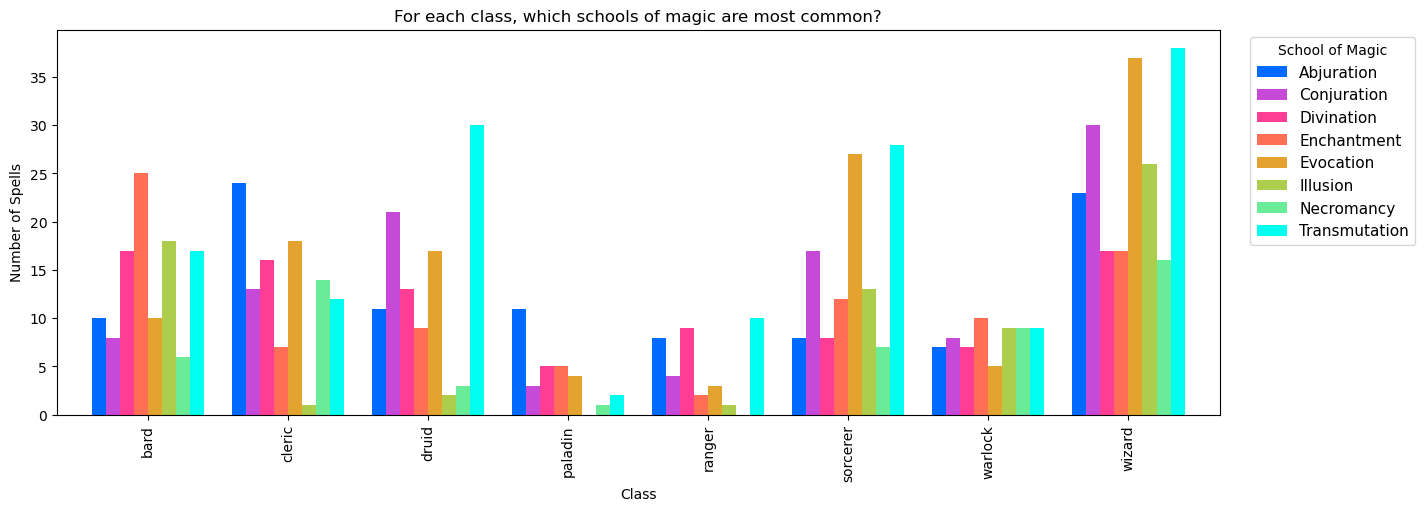

In [674]:
combinedGraph = combined_df.plot(kind = "bar", figsize = (15, 5), width = 0.8, title = "For each class, which schools of magic are most common?", color = ["#006aff", "#c749d7", "#ff3d94", "#ff6e55", "#e3a32e", "#adcd4c","#69eb98","#00fff0"])
plt.ylabel('Number of Spells')
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', prop={'size': 11})
legend.set_title("School of Magic")

In [675]:
x = combinedGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('combined_graph.png')

In [676]:
classSpellLists

,Spell Name,Spell Level,Spell School,Class,Subclass
0,Acid Arrow,2,evocation,wizard,all
3,Acid Splash,0,conjuration,sorcerer,all
4,Acid Splash,0,conjuration,wizard,all
6,Aid,2,abjuration,cleric,all
7,Aid,2,abjuration,paladin,all
...,...,...,...,...,...
1003,Wish,9,conjuration,wizard,all
1004,Word of Recall,6,conjuration,cleric,all
1005,Zone of Truth,2,enchantment,bard,all
1006,Zone of Truth,2,enchantment,cleric,all


In [677]:
spellcounts = classSpellLists['Spell Level'].value_counts()
sortedspellcounts = spellcounts.sort_index()

Text(0, 0.5, 'Number of Spells')

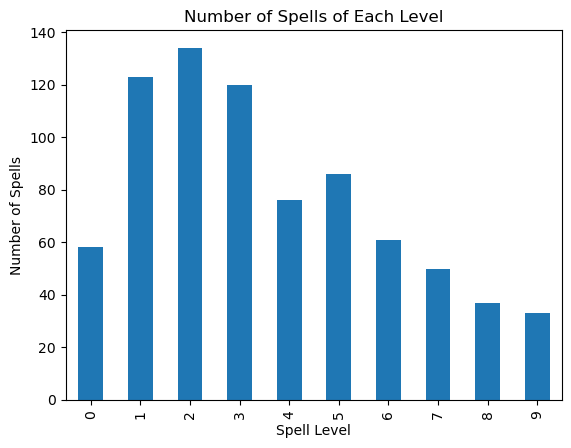

In [678]:
levelGraph = sortedspellcounts.plot(kind = "bar", title = "Number of Spells of Each Level")
plt.ylabel('Number of Spells')

In [679]:
x = levelGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('spell_level_graph.png')

In [680]:
spellcountsschool = classSpellLists['Spell School'].value_counts()
sortedspellcountsschool = spellcountsschool.sort_index()

Text(0, 0.5, 'Number of Spells')

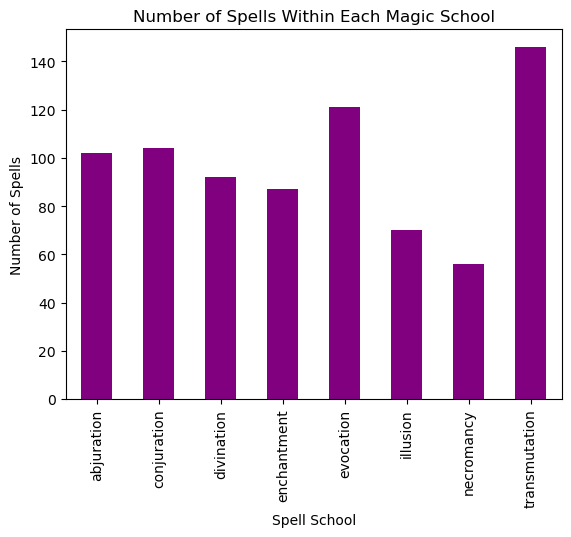

In [681]:
schoolGraph = sortedspellcountsschool.plot(kind = "bar", title = "Number of Spells Within Each Magic School", color = "purple")
plt.ylabel('Number of Spells')

In [682]:
x = schoolGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('spell_school_graph.png')

In [683]:
bard = classSpellLists['Class'] == 'bard'
cleric = classSpellLists['Class'] == 'cleric'
druid = classSpellLists['Class'] == 'druid'
paladin = classSpellLists['Class'] == 'paladin'
ranger = classSpellLists['Class'] == 'ranger'
sorcerer = classSpellLists['Class'] == 'sorcerer'
warlock = classSpellLists['Class'] == 'warlock'
wizard = classSpellLists['Class'] == 'wizard'

In [684]:
classSpellLists[bard].value_counts('Spell Level').sort_index()

Spell Level
0     9
1    19
2    19
3    15
4     8
5    16
6     7
7    10
8     5
9     3
Name: count, dtype: int64

In [685]:
bardSpells = classSpellLists[bard].value_counts('Spell Level').sort_index()
clericSpells = classSpellLists[cleric].value_counts('Spell Level').sort_index()
druidSpells = classSpellLists[druid].value_counts('Spell Level').sort_index()
paladinSpells = classSpellLists[paladin].value_counts('Spell Level').sort_index()
paladinSpells[int(0)] = 0
paladinSpells[int(6)] = 0
paladinSpells[int(7)] = 0
paladinSpells[int(8)] = 0
paladinSpells[int(9)] = 0
paladinSpells = paladinSpells.sort_index()
rangerSpells = classSpellLists[ranger].value_counts('Spell Level')
rangerSpells[int(0)] = 0
rangerSpells[int(6)] = 0
rangerSpells[int(7)] = 0
rangerSpells[int(8)] = 0
rangerSpells[int(9)] = 0
rangerSpells = rangerSpells.sort_index()
sorcererSpells = classSpellLists[sorcerer].value_counts('Spell Level').sort_index()
warlockSpells = classSpellLists[warlock].value_counts('Spell Level').sort_index()
wizardSpells = classSpellLists[wizard].value_counts('Spell Level').sort_index()

(0.0, 25.0)

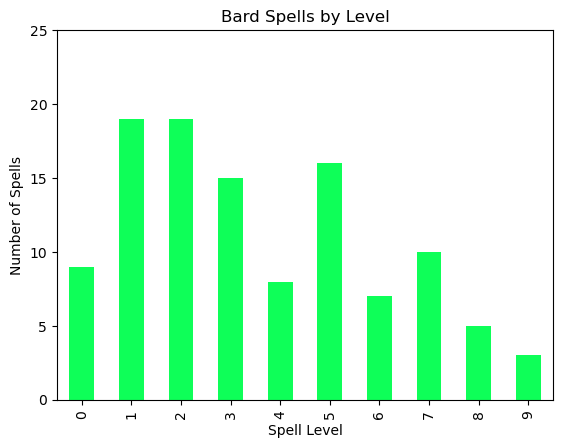

In [686]:
bardGraph = bardSpells.plot(kind = "bar", title = "Bard Spells by Level", color = "#0eff58")
plt.ylabel('Number of Spells')
plt.ylim(0, 25) 

In [687]:
x = bardGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('bard_graph.png')

(0.0, 25.0)

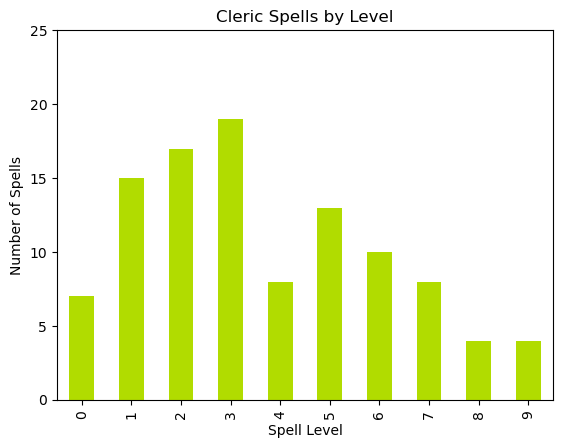

In [688]:
clericGraph = clericSpells.plot(kind = "bar", title = "Cleric Spells by Level", color = "#b1dc00")
plt.ylabel('Number of Spells')
plt.ylim(0, 25) 

In [689]:
x = clericGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('cleric_graph.png')

Text(0, 0.5, 'Number of Spells')

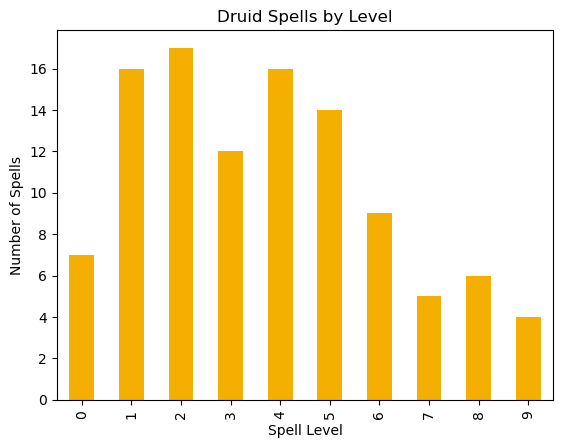

In [690]:
druidGraph = druidSpells.plot(kind = "bar", title = "Druid Spells by Level", color = "#f5af00")
plt.ylabel('Number of Spells')

In [691]:
x = druidGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('druid_graph.png')

Text(0, 0.5, 'Number of Spells')

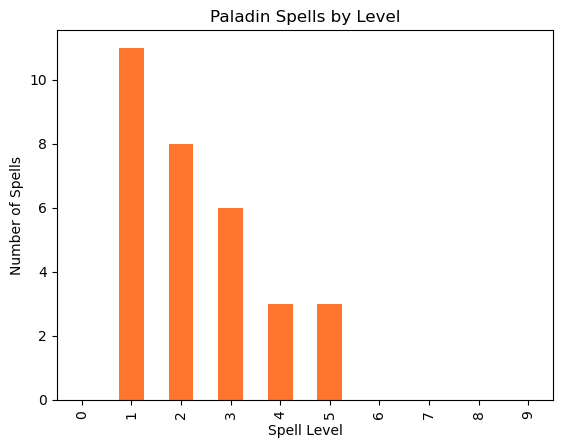

In [692]:
paladinGraph = paladinSpells.plot(kind = "bar", title = "Paladin Spells by Level", color = "#ff752d")
plt.ylabel('Number of Spells')

In [693]:
x = paladinGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('paladin_graph.png')

Text(0, 0.5, 'Number of Spells')

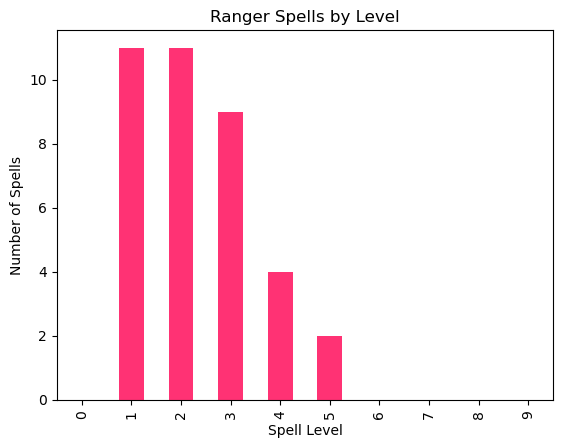

In [694]:
rangerGraph = rangerSpells.plot(kind = "bar", title = "Ranger Spells by Level", color = "#ff3274")
plt.ylabel('Number of Spells')

In [695]:
x = rangerGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('ranger_graph.png')

(0.0, 25.0)

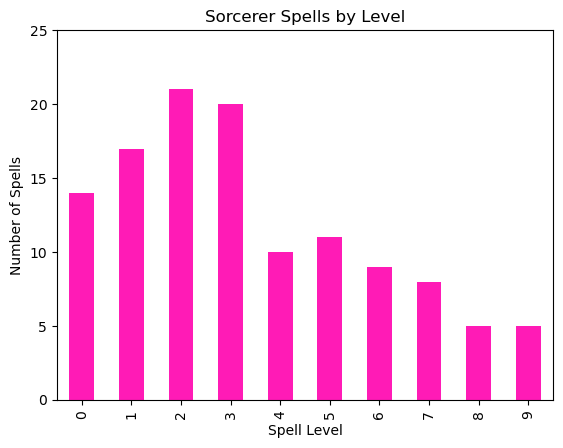

In [696]:
sorcererGraph = sorcererSpells.plot(kind = "bar", title = "Sorcerer Spells by Level", color = "#ff1bb6")
plt.ylabel('Number of Spells')
plt.ylim(0, 25) 

In [697]:
x = sorcererGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('sorcerer_graph.png')

Text(0, 0.5, 'Number of Spells')

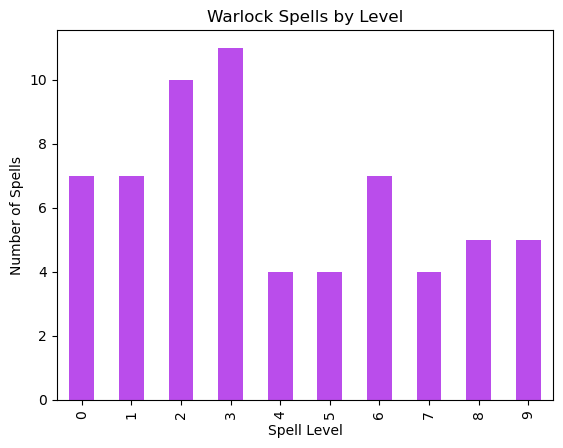

In [698]:
warlockGraph = warlockSpells.plot(kind = "bar", title = "Warlock Spells by Level", color = "#ba4deb")
plt.ylabel('Number of Spells')

In [699]:
x = warlockGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('warlock_graph.png')

Text(0, 0.5, 'Number of Spells')

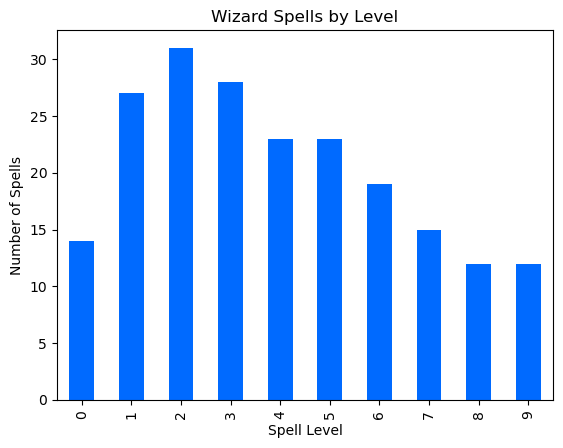

In [700]:
wizardGraph = wizardSpells.plot(kind = "bar", title = "Wizard Spells by Level", color = "#006aff")
plt.ylabel('Number of Spells')

In [701]:
x = wizardGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('wizard_graph.png')

In [702]:
combined_df = pd.merge(bardSpells, clericSpells, on='Spell Level')
combined_df = pd.merge(combined_df, druidSpells, on='Spell Level')
combined_df.columns = ['Bard', 'Cleric', 'Druid']
combined_df = pd.merge(combined_df, paladinSpells, on='Spell Level')
combined_df.columns = ['Bard', 'Cleric', 'Druid', 'Paladin']
combined_df = pd.merge(combined_df, rangerSpells, on='Spell Level')
combined_df.columns = ['Bard', 'Cleric', 'Druid', 'Paladin', 'Ranger']
combined_df = pd.merge(combined_df, sorcererSpells, on='Spell Level')
combined_df.columns = ['Bard', 'Cleric', 'Druid', 'Paladin', 'Ranger', 'Sorcerer']
combined_df = pd.merge(combined_df, warlockSpells, on='Spell Level')
combined_df.columns = ['Bard', 'Cleric', 'Druid', 'Paladin', 'Ranger', 'Sorcerer', 'Warlock']
combined_df = pd.merge(combined_df, wizardSpells, on='Spell Level')
combined_df.columns = ['Bard', 'Cleric', 'Druid', 'Paladin', 'Ranger', 'Sorcerer', 'Warlock', 'Wizard']
combined_df

,Bard,Cleric,Druid,Paladin,Ranger,Sorcerer,Warlock,Wizard
Spell Level,,,,,,,,
0,9,7,7,0,0,14,7,14
1,19,15,16,11,11,17,7,27
2,19,17,17,8,11,21,10,31
3,15,19,12,6,9,20,11,28
4,8,8,16,3,4,10,4,23
5,16,13,14,3,2,11,4,23
6,7,10,9,0,0,9,7,19
7,10,8,5,0,0,8,4,15
8,5,4,6,0,0,5,5,12


Text(0, 0.5, 'Number of Spells')

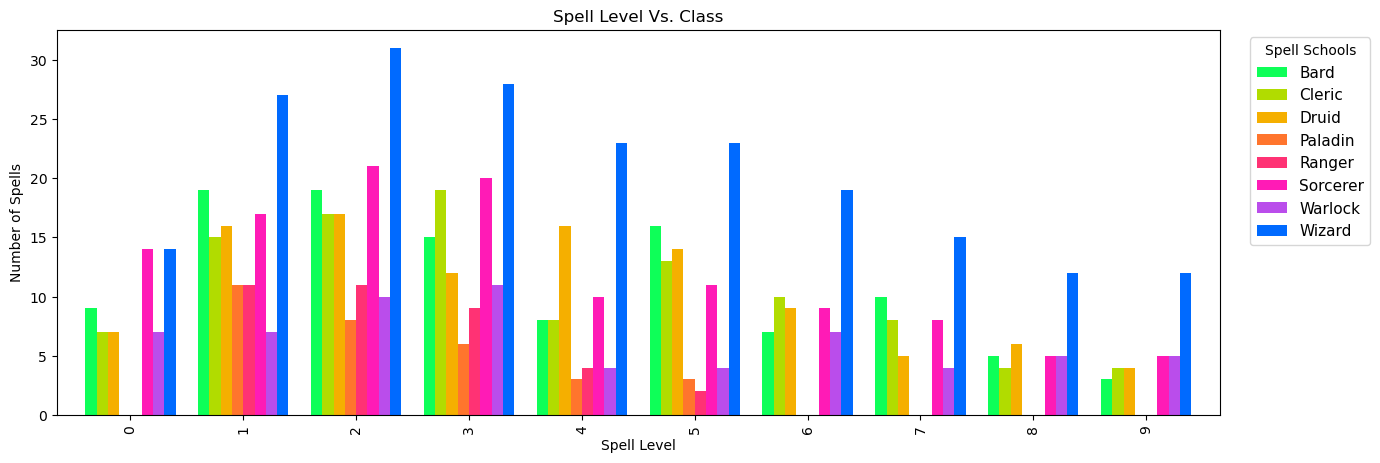

In [703]:
combinedSpellGraph = combined_df.plot(kind = "bar", figsize = (15, 5), width = 0.8, title = "Spell Level Vs. Class", color = ["#0eff58", "#b1dc00", "#f5af00", "#ff752d","#ff3274","#ff1bb6","#ba4deb","#006aff"])
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', prop={'size': 11})
legend.set_title("Spell Schools")
plt.ylabel('Number of Spells')

In [704]:
x = combinedSpellGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('class_spell_graph.png')

In [705]:
classSpellLists = df[df['Subclass'] == 'all']
classSpellLists

,Spell Name,Spell Level,Spell School,Class,Subclass
0,Acid Arrow,2,evocation,wizard,all
3,Acid Splash,0,conjuration,sorcerer,all
4,Acid Splash,0,conjuration,wizard,all
6,Aid,2,abjuration,cleric,all
7,Aid,2,abjuration,paladin,all
...,...,...,...,...,...
1003,Wish,9,conjuration,wizard,all
1004,Word of Recall,6,conjuration,cleric,all
1005,Zone of Truth,2,enchantment,bard,all
1006,Zone of Truth,2,enchantment,cleric,all


In [706]:
cantrip = classSpellLists['Spell Level'] == 0
levelone = classSpellLists['Spell Level'] == 1
leveltwo = classSpellLists['Spell Level'] == 2
levelthree = classSpellLists['Spell Level'] == 3
levelfour = classSpellLists['Spell Level'] == 4
levelfive = classSpellLists['Spell Level'] == 5
levelsix = classSpellLists['Spell Level'] == 6
levelseven = classSpellLists['Spell Level'] == 7
leveleight = classSpellLists['Spell Level'] == 8
levelnine = classSpellLists['Spell Level'] == 9

In [707]:
cantripSchools = classSpellLists[cantrip].value_counts('Spell School').sort_index()
leveloneSchools = classSpellLists[levelone].value_counts('Spell School').sort_index()
leveltwoSchools = classSpellLists[leveltwo].value_counts('Spell School').sort_index()
levelthreeSchools = classSpellLists[levelthree].value_counts('Spell School').sort_index()
levelthreeSchools['enchantment'] = 0
levelthreeSchools = levelthreeSchools.sort_index()
levelfourSchools = classSpellLists[levelfour].value_counts('Spell School').sort_index()
levelfiveSchools = classSpellLists[levelfive].value_counts('Spell School').sort_index()
levelsixSchools = classSpellLists[levelsix].value_counts('Spell School').sort_index()
levelsevenSchools = classSpellLists[levelseven].value_counts('Spell School').sort_index()
levelsevenSchools ['enchantment'] = 0
levelsevenSchools['divination'] = 0
levelsevenSchools = levelsevenSchools.sort_index()
leveleightSchools = classSpellLists[leveleight].value_counts('Spell School').sort_index()
leveleightSchools['enchantment'] = 0
leveleightSchools['divination'] = 0
leveleightSchools = leveleightSchools.sort_index()
levelnineSchools = classSpellLists[levelnine].value_counts('Spell School').sort_index()

Text(0, 0.5, 'Number of Spells')

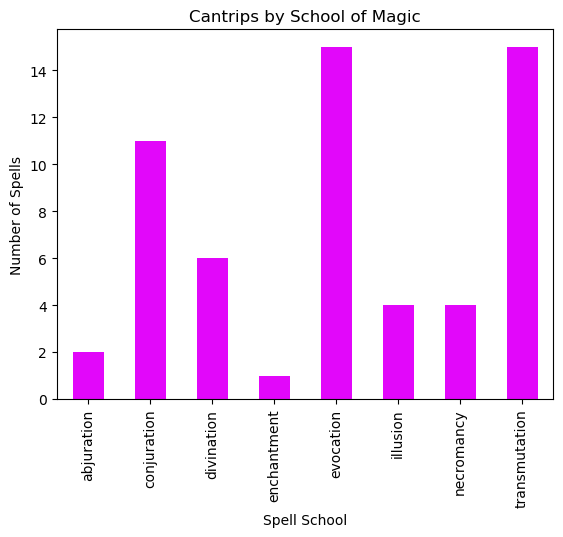

In [708]:
cantripGraph = cantripSchools.plot(kind = "bar", title = "Cantrips by School of Magic", color = "#E207FA")
plt.ylabel('Number of Spells')

In [709]:
x = cantripGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('cantrips_schools.png')

Text(0, 0.5, 'Number of Spells')

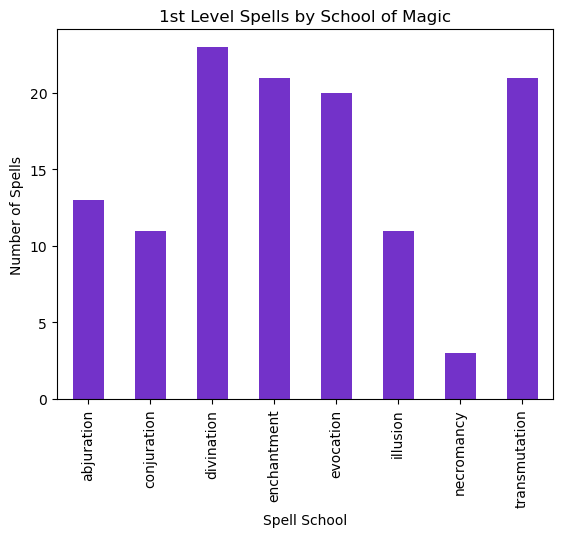

In [710]:
leveloneGraph = leveloneSchools.plot(kind = "bar", title = "1st Level Spells by School of Magic", color = "#7332C9")
plt.ylabel('Number of Spells')

In [711]:
x = leveloneGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl1_schools.png')

Text(0, 0.5, 'Number of Spells')

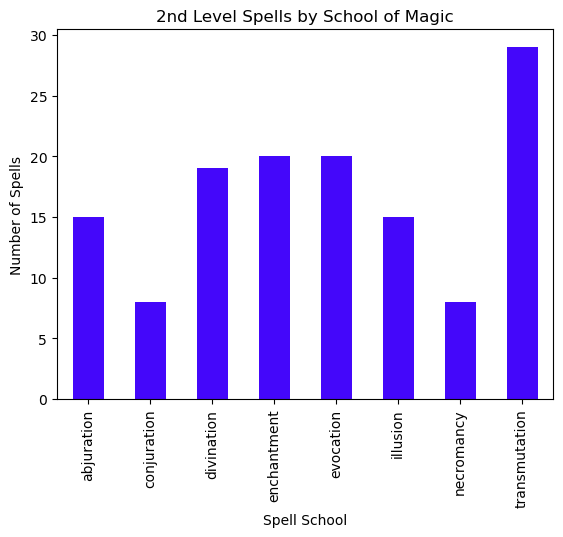

In [712]:
leveltwoGraph = leveltwoSchools.plot(kind = "bar", title = "2nd Level Spells by School of Magic", color = "#4407FA")
plt.ylabel('Number of Spells')

In [713]:
x = leveltwoGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl2_schools.png')

Text(0, 0.5, 'Number of Spells')

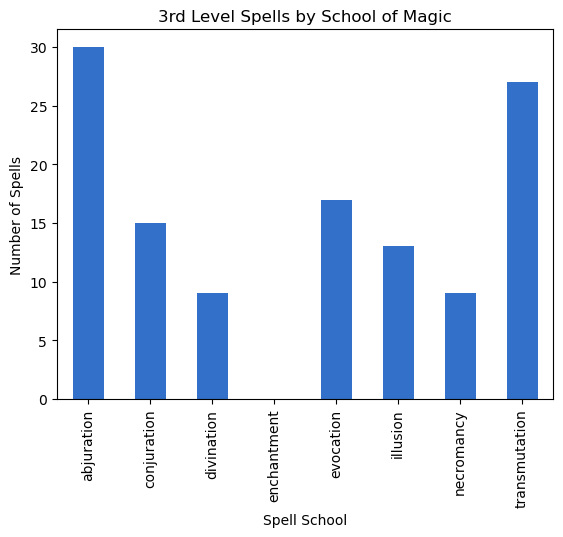

In [714]:
levelthreeGraph = levelthreeSchools.plot(kind = "bar", title = "3rd Level Spells by School of Magic", color = "#3270C9")
plt.ylabel('Number of Spells')

In [715]:
x = levelthreeGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl3_schools.png')

Text(0, 0.5, 'Number of Spells')

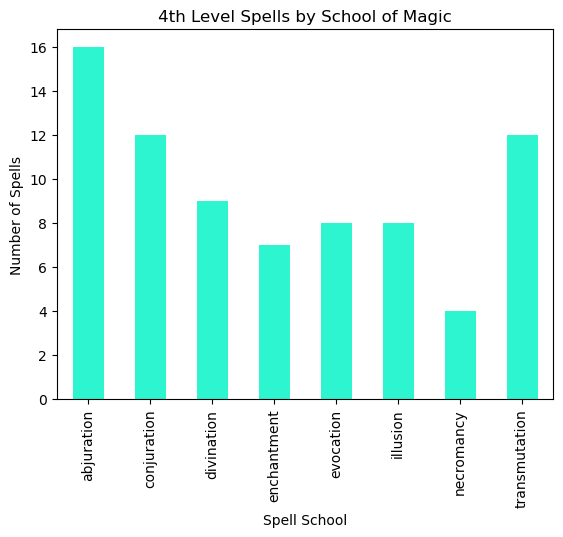

In [716]:
levelfourGraph = levelfourSchools.plot(kind = "bar", title = "4th Level Spells by School of Magic", color = "#2CF5D0")
plt.ylabel('Number of Spells')

In [717]:
x = levelfourGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl4_schools.png')

Text(0, 0.5, 'Number of Spells')

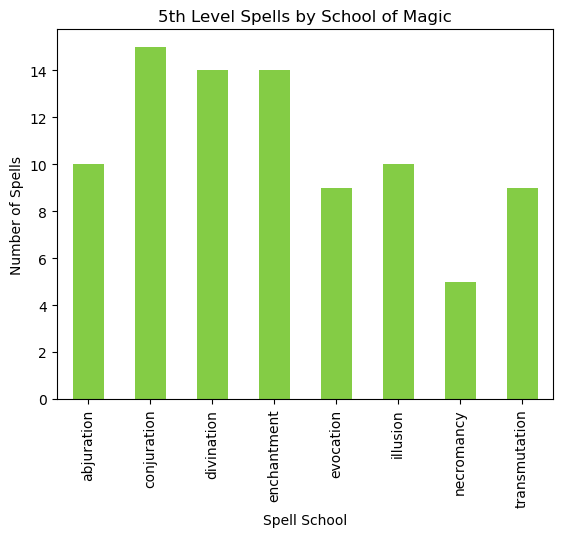

In [718]:
levelfiveGraph = levelfiveSchools.plot(kind = "bar", title = "5th Level Spells by School of Magic", color = "#84cc45")
plt.ylabel('Number of Spells')

In [719]:
x = levelfiveGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl5_schools.png')

Text(0, 0.5, 'Number of Spells')

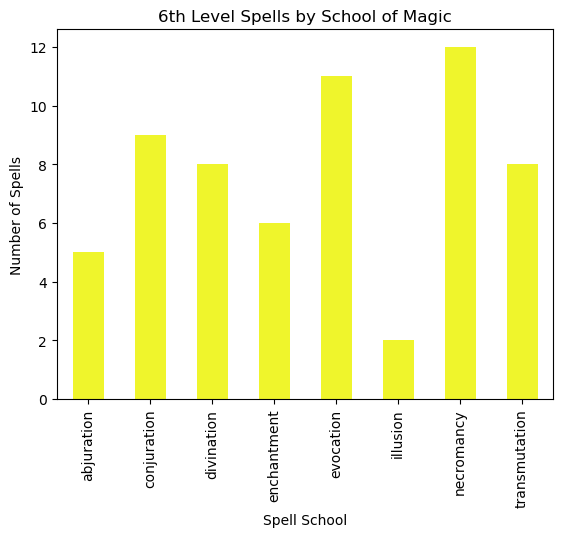

In [720]:
levelsixGraph = levelsixSchools.plot(kind = "bar", title = "6th Level Spells by School of Magic", color = "#EFF52C")
plt.ylabel('Number of Spells')

In [721]:
x = levelsixGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl6_schools.png')

Text(0, 0.5, 'Number of Spells')

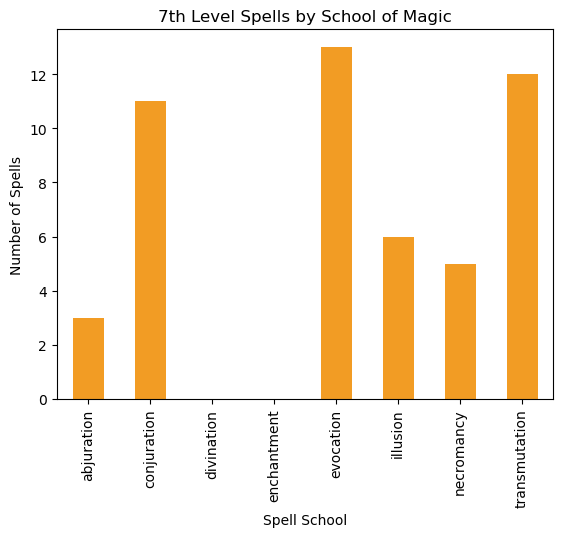

In [722]:
levelsevenGraph = levelsevenSchools.plot(kind = "bar", title = "7th Level Spells by School of Magic", color = "#F29C24")
plt.ylabel('Number of Spells')

In [723]:
x = levelsevenGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl7_schools.png')

Text(0, 0.5, 'Number of Spells')

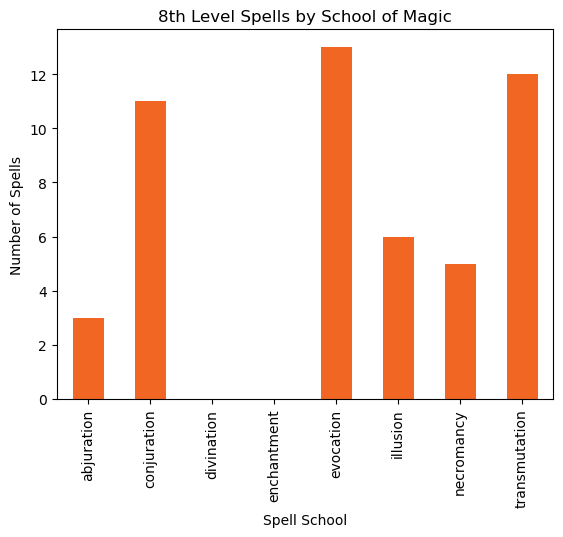

In [724]:
leveleightGraph = levelsevenSchools.plot(kind = "bar", title = "8th Level Spells by School of Magic", color = "#F26624")
plt.ylabel('Number of Spells')

In [725]:
x = leveleightGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl8_schools.png')

Text(0, 0.5, 'Number of Spells')

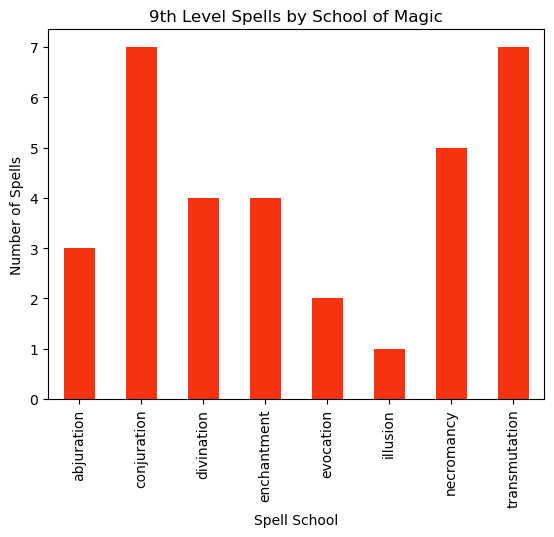

In [726]:
levelnineGraph = levelnineSchools.plot(kind = "bar", title = "9th Level Spells by School of Magic", color = "#F53311")
plt.ylabel('Number of Spells')

In [727]:
x = levelnineGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('lvl9_schools.png')

In [728]:
combined_df = pd.merge(cantripSchools, leveloneSchools, on='Spell School')
combined_df = pd.merge(combined_df, leveltwoSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level']
combined_df = pd.merge(combined_df, levelthreeSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level']
combined_df = pd.merge(combined_df, levelfourSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level', '4th Level']
combined_df = pd.merge(combined_df, levelfiveSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level', '4th Level', '5th Level']
combined_df = pd.merge(combined_df, levelsixSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level', '4th Level', '5th Level', '6th Level']
combined_df = pd.merge(combined_df, levelsevenSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level', '4th Level', '5th Level', '6th Level', '7th Level']
combined_df = pd.merge(combined_df, leveleightSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level', '4th Level', '5th Level', '6th Level', '7th Level', '8th Level']
combined_df = pd.merge(combined_df, levelnineSchools, on='Spell School')
combined_df.columns = ['Cantrips', '1st Level', '2nd Level', '3rd Level', '4th Level', '5th Level', '6th Level', '7th Level', '8th Level', '9th Level']
combined_df = combined_df.T

Text(0, 0.5, 'Number of Spells')

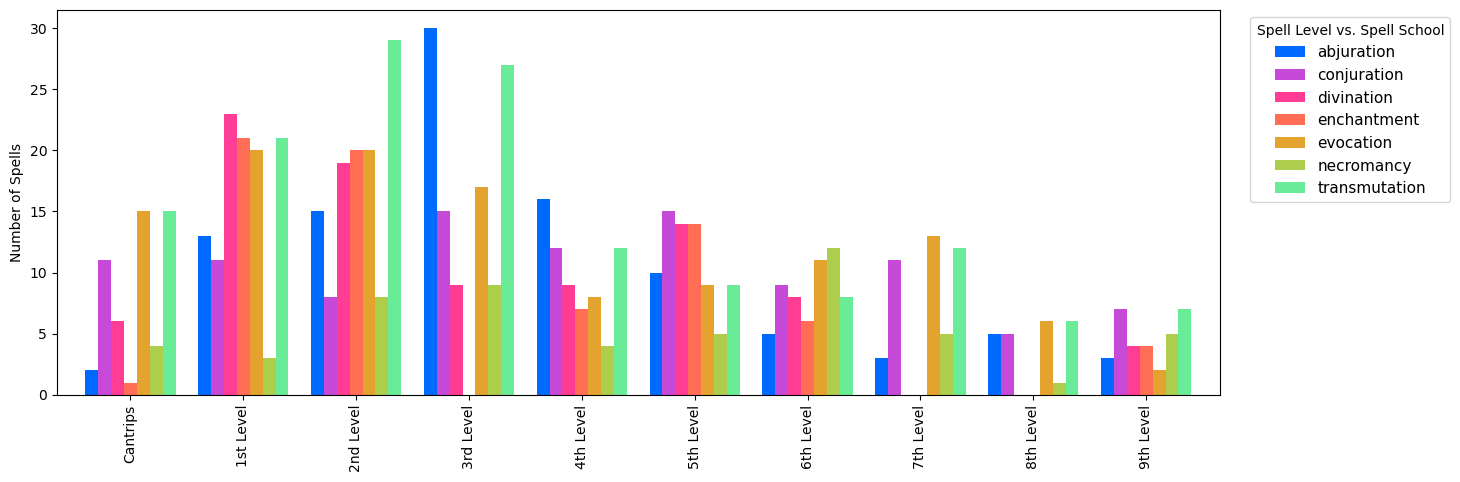

In [729]:
combinedGraph = combined_df.plot( kind = "bar", figsize = (15, 5), width = 0.8, color = ["#006aff", "#c749d7", "#ff3d94", "#ff6e55", "#e3a32e", "#adcd4c","#69eb98","#00fff0"])
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', prop={'size': 11})
legend.set_title("Spell Level vs. Spell School")
plt.ylabel('Number of Spells')

In [730]:
x = combinedGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('all_lvls_graph.png')

In [731]:
numberOfClasses = classSpellLists.value_counts('Spell Name')

In [732]:
numberOfClasses

Spell Name
Detect Magic         7
Dispel Magic         7
Hold Person          6
Locate Creature      6
Locate Object        6
                    ..
Meld Into Stone      1
Maze                 1
Mass Healing Word    1
Mass Heal            1
Acid Arrow           1
Name: count, Length: 319, dtype: int64

In [733]:
classesPerSpell = numberOfClasses.value_counts().sort_index()

Text(0.5, 0, 'Number of Classes')

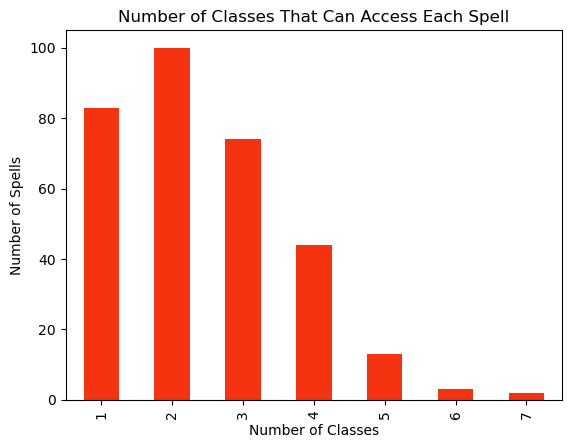

In [734]:
classesPerSpellGraph = classesPerSpell.plot(kind = "bar", title = "Number of Classes That Can Access Each Spell", color = "#F53311")
plt.ylabel('Number of Spells')
plt.xlabel('Number of Classes')

In [735]:
numberOfClasses.to_csv('classes_per_spell.csv')

In [736]:
x = classesPerSpellGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('classes_per_spell_graph.png')

In [737]:
numberOfClasses.to_csv('classes_per_spell.csv')

In [738]:
combined_df = pd.merge(numberOfClasses, classSpellLists, on='Spell Name')

In [739]:
combined_df = combined_df.drop_duplicates(subset=['Spell Name'])
combined_df = combined_df.drop(columns = ['Class', 'Subclass', 'Spell Level'])

In [740]:
oneclass = combined_df['count'] == 1
twoclasses = combined_df['count'] == 2
threeclasses = combined_df['count'] == 3
fourclasses = combined_df['count'] == 4
fiveclasses = combined_df['count'] == 5
sixclasses = combined_df['count'] == 6
sevenclasses = combined_df['count'] == 7

In [741]:
oneSchool = combined_df[oneclass].value_counts('Spell School').sort_index()
twoSchools = combined_df[twoclasses].value_counts('Spell School').sort_index()
threeSchools = combined_df[threeclasses].value_counts('Spell School').sort_index()
fourSchools = combined_df[fourclasses].value_counts('Spell School').sort_index()
fiveSchools = combined_df[fiveclasses].value_counts('Spell School').sort_index()
fiveSchools['illusion'] = 0
fiveSchools['necromancy'] = 0
fiveSchools = fiveSchools.sort_index()
sixSchools = combined_df[sixclasses].value_counts('Spell School').sort_index()
sixSchools['abjuration'] = 0
sixSchools['conjuration'] = 0
sixSchools['evocation'] = 0
sixSchools['illusion'] = 0
sixSchools['necromancy'] = 0
sixSchools['transmutation'] = 0
sixSchools = sixSchools.sort_index()
sevenSchools = combined_df[sevenclasses].value_counts('Spell School').sort_index()
sevenSchools['conjuration'] = 0
sevenSchools['enchantment'] = 0
sevenSchools['evocation'] = 0
sevenSchools['illusion'] = 0
sevenSchools['necromancy'] = 0
sevenSchools['transmutation'] = 0
sevenSchools = sevenSchools.sort_index()

Text(0, 0.5, 'Number of Spells')

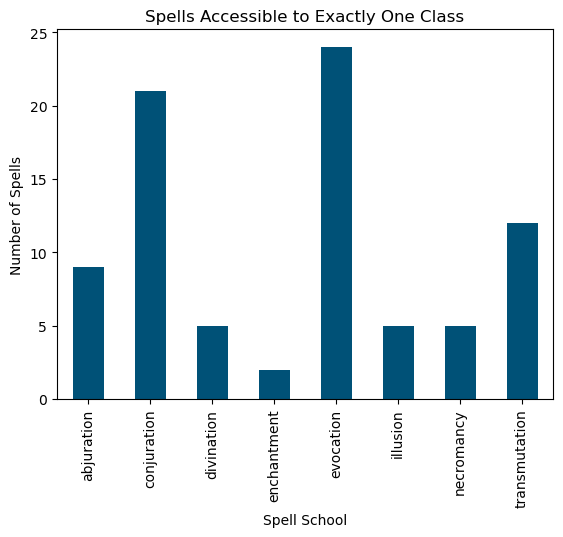

In [742]:
oneSchoolPlot = oneSchool.plot(kind = "bar", title = "Spells Accessible to Exactly One Class", color = "#005177")
plt.ylabel('Number of Spells')

In [743]:
x = oneSchoolPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('oneschool_graph.png')

Text(0, 0.5, 'Number of Spells')

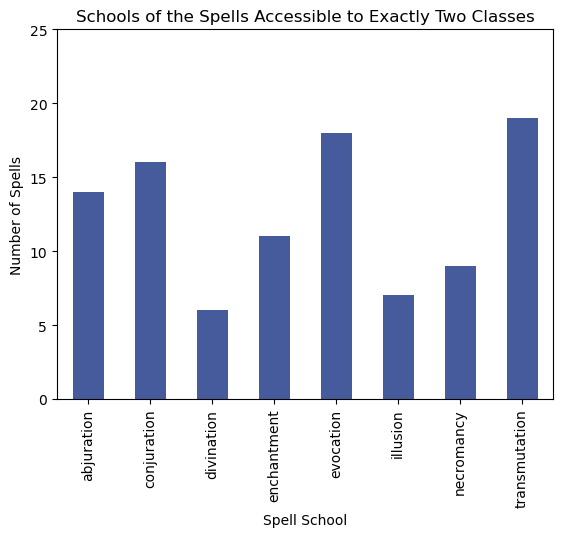

In [744]:
twoSchoolsPlot = twoSchools.plot(kind = "bar", title = "Schools of the Spells Accessible to Exactly Two Classes", color = "#455b9b")
plt.ylim(0, 25) 
plt.ylabel('Number of Spells')

In [745]:
x = twoSchoolsPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('twoschools_graph.png')

Text(0, 0.5, 'Number of Spells')

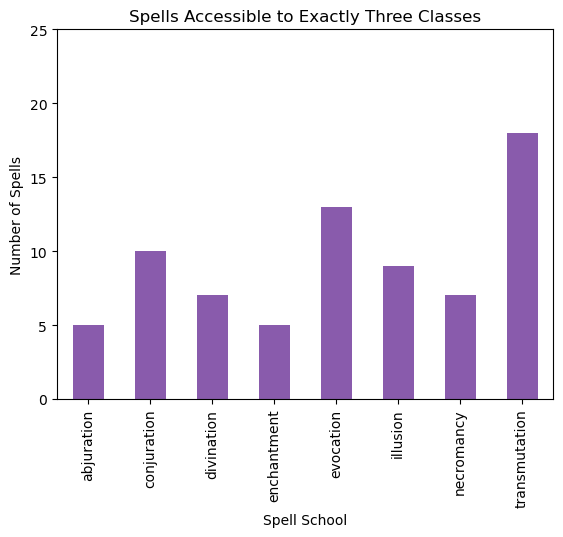

In [746]:
threeSchoolsPlot = threeSchools.plot(kind = "bar", title = "Spells Accessible to Exactly Three Classes", color = "#895bac")
plt.ylim(0, 25) 
plt.ylabel('Number of Spells')

In [747]:
x = threeSchoolsPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('threeschools_graph.png')

Text(0, 0.5, 'Number of Spells')

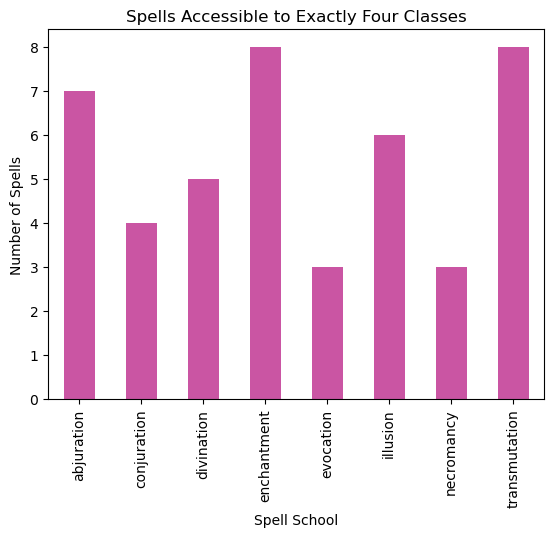

In [748]:
fourSchoolsPlot = fourSchools.plot(kind = "bar", title = "Spells Accessible to Exactly Four Classes", color = "#ca55a3")
plt.ylabel('Number of Spells')

In [749]:
x = fourSchoolsPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('fourschools_graph.png')

Text(0, 0.5, 'Number of Spells')

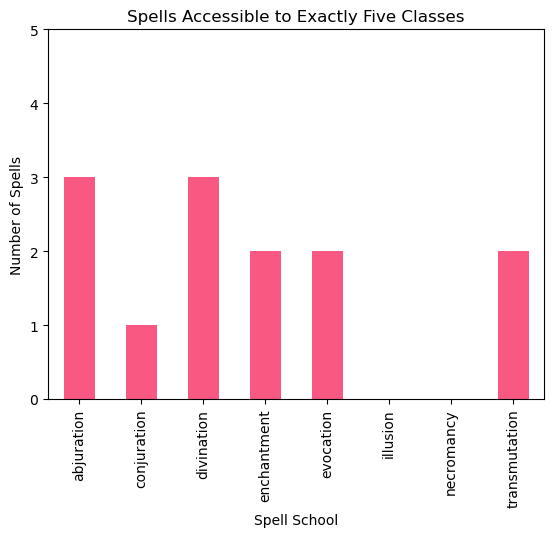

In [750]:
fiveSchoolsPlot = fiveSchools.plot(kind = "bar", title = "Spells Accessible to Exactly Five Classes", color = "#f95882")
plt.ylim(0, 5) 
plt.ylabel('Number of Spells')

In [751]:
x = fiveSchoolsPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('fiveschools_graph.png')

Text(0, 0.5, 'Number of Spells')

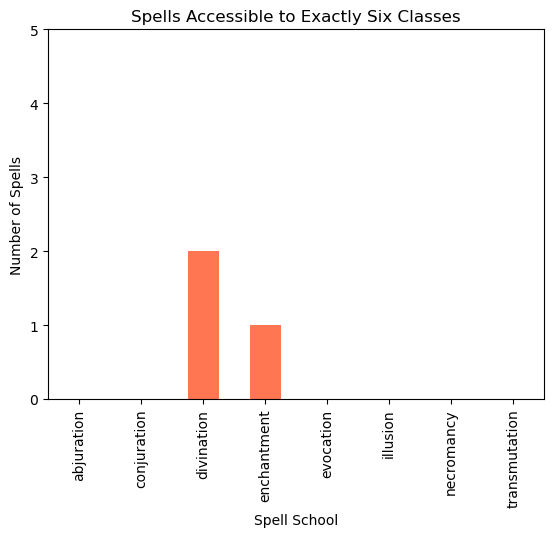

In [752]:
sixSchoolsPlot = sixSchools.plot(kind = "bar", title = "Spells Accessible to Exactly Six Classes", color = "#ff7652")
plt.ylim(0, 5) 
plt.ylabel('Number of Spells')

In [753]:
x = sixSchoolsPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('sixschools_graph.png')

Text(0, 0.5, 'Number of Spells')

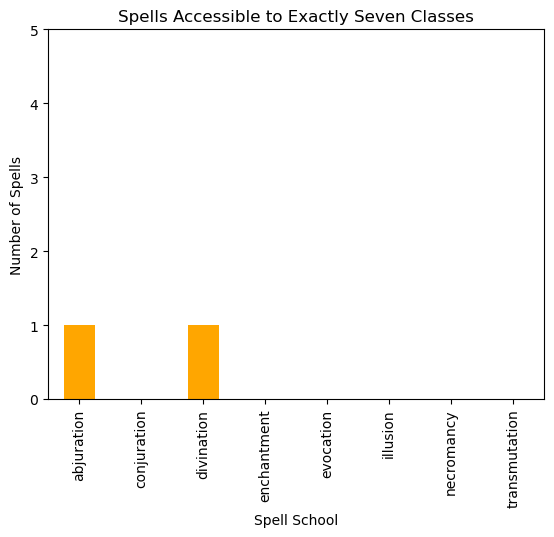

In [754]:
sevenSchoolsPlot = sevenSchools.plot(kind = "bar", title = "Spells Accessible to Exactly Seven Classes", color = "#ffa600")
plt.ylim(0, 5) 
plt.ylabel('Number of Spells')

In [755]:
x = sevenSchoolsPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('sevenschools_graph.png')

In [756]:
combineddf = pd.merge(oneSchool, twoSchools, on='Spell School')
combineddf = pd.merge(combineddf, threeSchools, on='Spell School')
combineddf.columns = ['1 Class', '2 Classes', '3 Classes']
combineddf = pd.merge(combineddf, fourSchools, on='Spell School')
combineddf.columns = ['1 Class', '2 Classes', '3 Classes', '4 Classes']
combineddf = pd.merge(combineddf, fiveSchools, on='Spell School')
combineddf.columns = ['1 Class', '2 Classes', '3 Classes', '4 Classes', '5 Classes']
combineddf = pd.merge(combineddf, sixSchools, on='Spell School')
combineddf.columns = ['1 Class', '2 Classes', '3 Classes', '4 Classes', '5 Classes', '6 Classes']
combineddf = pd.merge(combineddf, sevenSchools, on='Spell School')
combineddf.columns = ['1 Class', '2 Classes', '3 Classes', '4 Classes', '5 Classes', '6 Classes', '7 Classes']
combineddf

,1 Class,2 Classes,3 Classes,4 Classes,5 Classes,6 Classes,7 Classes
Spell School,,,,,,,
abjuration,9,14,5,7,3,0,1
conjuration,21,16,10,4,1,0,0
divination,5,6,7,5,3,2,1
enchantment,2,11,5,8,2,1,0
evocation,24,18,13,3,2,0,0
illusion,5,7,9,6,0,0,0
necromancy,5,9,7,3,0,0,0
transmutation,12,19,18,8,2,0,0


Text(0, 0.5, 'Number of Spells')

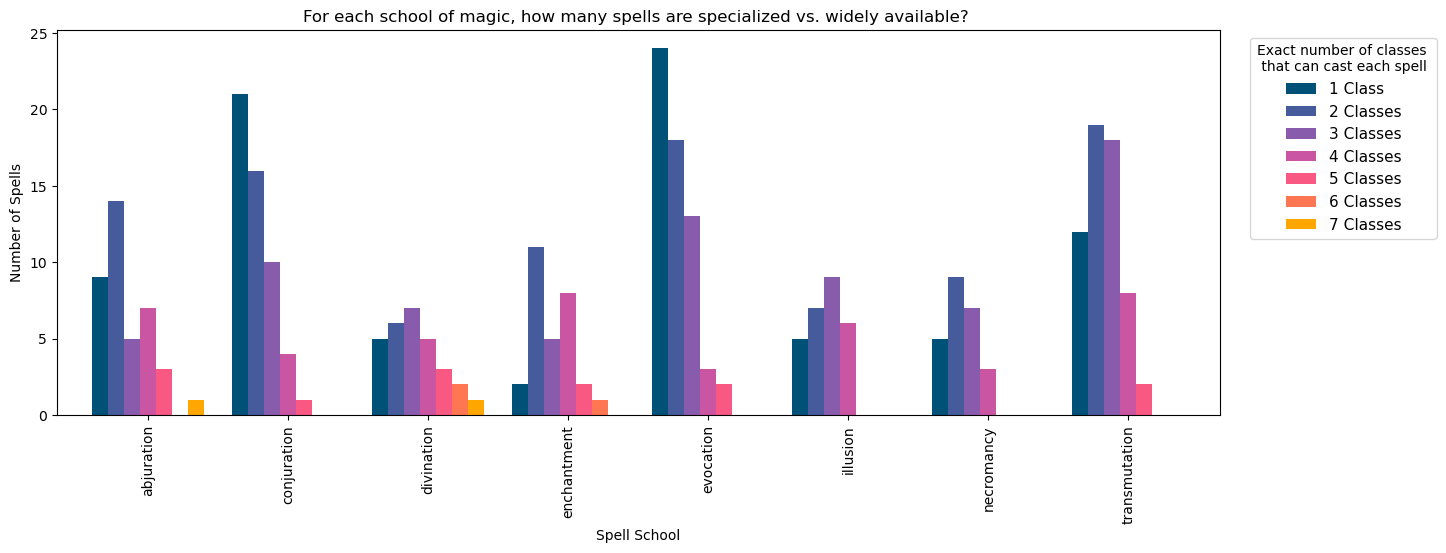

In [757]:
combinedGraph = combineddf.plot(kind = "bar", figsize = (15, 5), width = 0.8, title = "For each school of magic, how many spells are specialized vs. widely available? ",  color = ["#005177","#455b9b","#895bac","#ca55a3","#f95882","#ff7652","#ffa600"])
legend = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', prop={'size': 11})
legend.set_title("Exact number of classes \n that can cast each spell")
plt.ylabel('Number of Spells')

In [758]:
x = combinedGraph.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('allschools_graph.png')

In [759]:
oneclasstotal = combined_df['count'] >= 1
twoclasstotal = combined_df['count'] >= 2
threeclasstotal = combined_df['count'] >= 3
fourclasstotal = combined_df['count'] >= 4
fiveclasstotal = combined_df['count'] >= 5
sixclasstotal = combined_df['count'] >= 6
sevenclasstotal = combined_df['count'] >= 7

In [779]:
oneSchoolTotal = combined_df[oneclasstotal].value_counts('Spell School').sort_index()
twoSchoolTotal = combined_df[twoclasstotal].value_counts('Spell School').sort_index()
threeSchoolTotal = combined_df[threeclasstotal].value_counts('Spell School').sort_index()
fourSchoolTotal = combined_df[fourclasstotal].value_counts('Spell School').sort_index()
fiveSchoolTotal = combined_df[fiveclasstotal].value_counts('Spell School').sort_index()
fiveSchoolTotal['illusion'] = 0
fiveSchoolTotal['necromancy'] = 0
fiveSchoolTotal = fiveSchools.sort_index()
sixSchoolTotal = combined_df[sixclasstotal].value_counts('Spell School').sort_index()
sixSchoolTotal['conjuration'] = 0
sixSchoolTotal['evocation'] = 0
sixSchoolTotal['illusion'] = 0
sixSchoolTotal['necromancy'] = 0
sixSchoolTotal['transmutation'] = 0
sixSchoolTotal = sixSchoolTotal.sort_index()
sevenSchoolTotal = combined_df[sevenclasstotal].value_counts('Spell School').sort_index()
sevenSchoolTotal['conjuration'] = 0
sevenSchoolTotal['enchantment'] = 0
sevenSchoolTotal['evocation'] = 0
sevenSchoolTotal['illusion'] = 0
sevenSchoolTotal['necromancy'] = 0
sevenSchoolTotal['transmutation'] = 0
sevenSchoolTotal = sevenSchoolTotal.sort_index()

In [780]:
oneSchoolTotal

Spell School
abjuration       39
conjuration      52
divination       29
enchantment      29
evocation        60
illusion         27
necromancy       24
transmutation    59
Name: count, dtype: int64

Text(0, 0.5, 'Number of Spells')

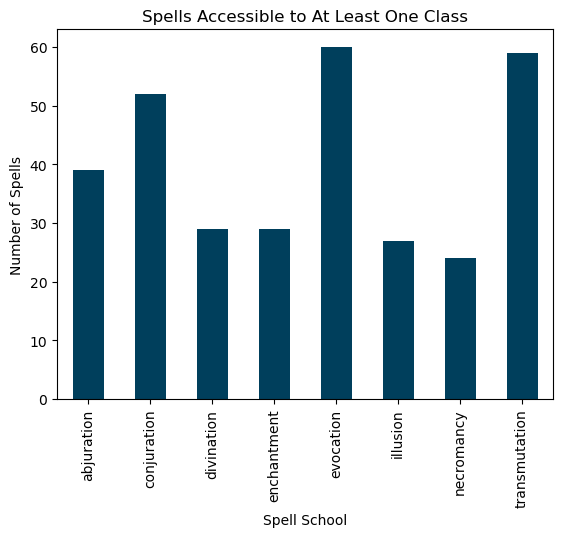

In [781]:
oneSchoolTotalPlot = oneSchoolTotal.plot(kind = "bar", title = "Spells Accessible to At Least One Class", color = "#003f5c")
plt.ylabel('Number of Spells')

In [782]:
x = oneSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('oneschooltotal_graph.png')

Text(0, 0.5, 'Number of Spells')

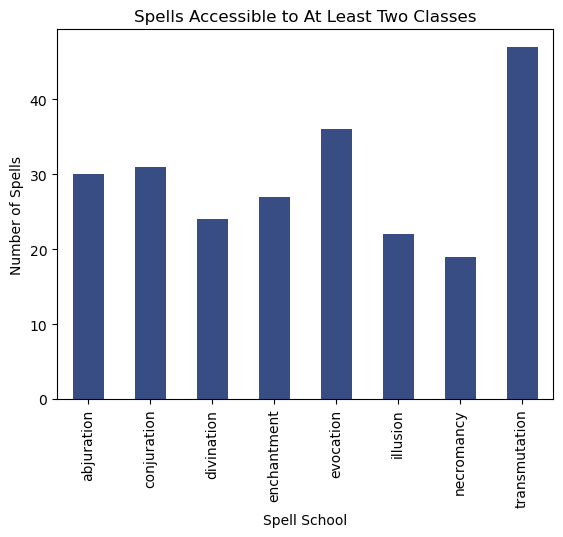

In [783]:
twoSchoolTotalPlot = twoSchoolTotal.plot(kind = "bar", title = "Spells Accessible to At Least Two Classes", color = "#374d84")
plt.ylabel('Number of Spells')

In [784]:
x = twoSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('twoschooltotal_graph.png')

Text(0, 0.5, 'Number of Spells')

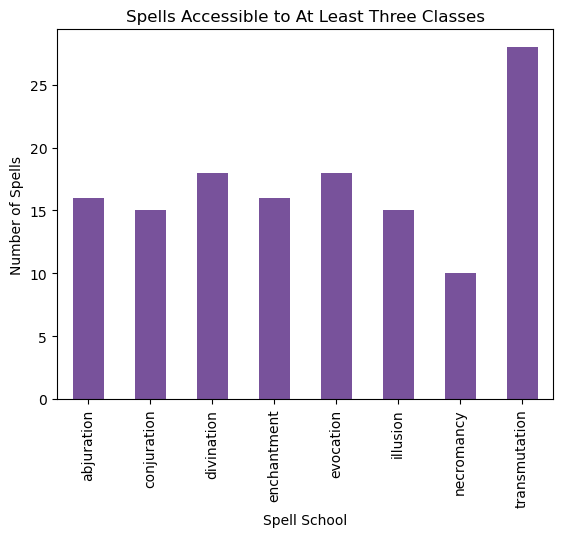

In [785]:
threeSchoolTotalPlot = threeSchoolTotal.plot(kind = "bar", title = "Spells Accessible to At Least Three Classes", color = "#78529b")
plt.ylabel('Number of Spells')

In [786]:
x = threeSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('threeschooltotal_graph.png')

Text(0, 0.5, 'Number of Spells')

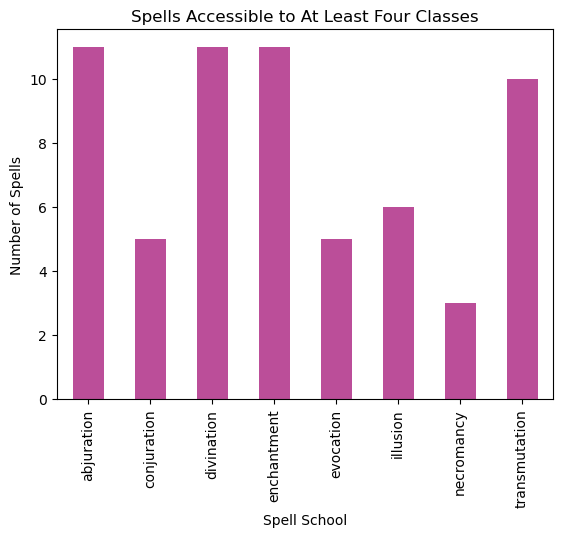

In [787]:
fourSchoolTotalPlot = fourSchoolTotal.plot(kind = "bar", title = "Spells Accessible to At Least Four Classes", color = "#bb4e99")
plt.ylabel('Number of Spells')

In [788]:
x = fourSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('fourschooltotal_graph.png')

Text(0, 0.5, 'Number of Spells')

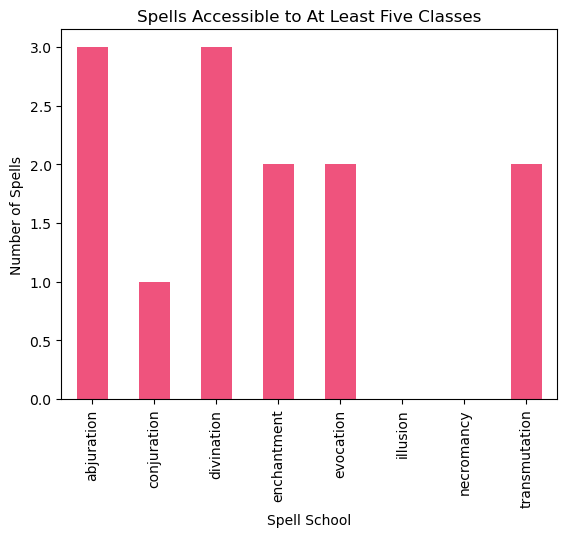

In [789]:
fiveSchoolTotalPlot = fiveSchoolTotal.plot(kind = "bar", title = "Spells Accessible to At Least Five Classes", color = "#ef537d")
plt.ylabel('Number of Spells')

In [790]:
x = fiveSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('fiveschooltotal_graph.png')

(0.0, 5.0)

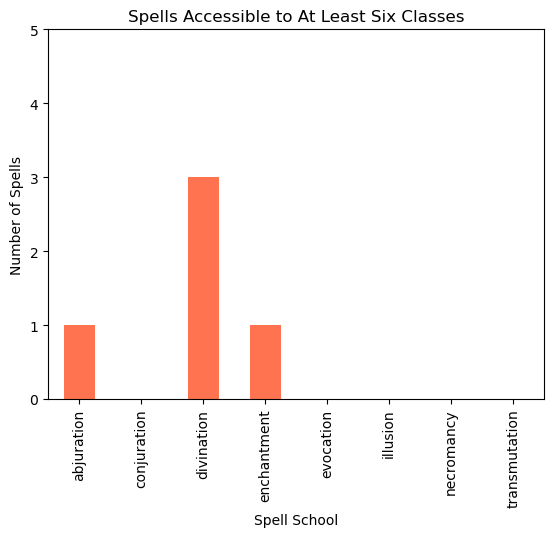

In [791]:
sixSchoolTotalPlot = sixSchoolTotal.plot(kind = "bar", title = "Spells Accessible to At Least Six Classes", color = "#ff7350")
plt.ylabel('Number of Spells')
plt.ylim(0,5)

In [792]:
x = sixSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('sixschooltotal_graph.png')

(0.0, 5.0)

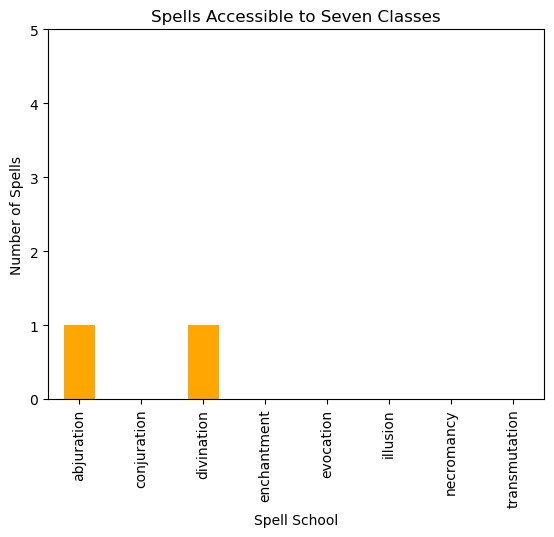

In [793]:
sevenSchoolTotalPlot = sevenSchoolTotal.plot(kind = "bar", title = "Spells Accessible to Seven Classes", color = "#ffa600")
plt.ylabel('Number of Spells')
plt.ylim(0,5)

In [794]:
x = sevenSchoolTotalPlot.get_figure()
fig = x.get_figure()
fig.tight_layout()
fig.savefig('sevenschooltotal_graph.png')